<a href="https://colab.research.google.com/github/iiwalter/nps-preditivo/blob/main/nps_preditivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nesta primeira etapa, estamos organizando as 'ferramentas' essenciais que nos ajudarão a analisar e visualizar os dados.

In [ ]:
import pandas as pd
import numpy as np

# Libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt


Aqui, carregamos nossos dados de pesquisa NPS (satisfação do cliente) para dentro do sistema. Mostramos as primeiras linhas para ter uma ideia rápida do que estamos olhando.

In [ ]:
nps_data = pd.read_csv('desafio_nps_fase_1.csv')

nps_data.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


Avaliando o tamanho da base de dados

In [ ]:
nps_data.shape

(2500, 19)

Aqui, verificamos o tipo de informação em cada coluna, por exemplo, se é um número, um texto ou uma data. Isso é importante para garantir que as análises sejam feitas corretamente.

In [ ]:
nps_data.dtypes

,0
customer_id,int64
customer_age,int64
customer_region,object
customer_tenure_months,int64
order_id,int64
order_value,float64
items_quantity,int64
discount_value,float64
payment_installments,int64
delivery_time_days,int64


Esta lista nos mostra todos os títulos das informações que temos sobre nossos clientes, como idade, região, tempo de entrega, etc.

In [ ]:
nps_data.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

Confirmamos se há alguma informação faltando em nossa base de dados. Um resultado 'zero' significa que não temos dados importantes nulos, o que é essencial para a qualidade da análise.

In [ ]:
nps_data.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


Construindo uma amostra aleatória para estimar a média de NPS com incerteza controlada.

<Axes: xlabel='nps_score', ylabel='Count'>

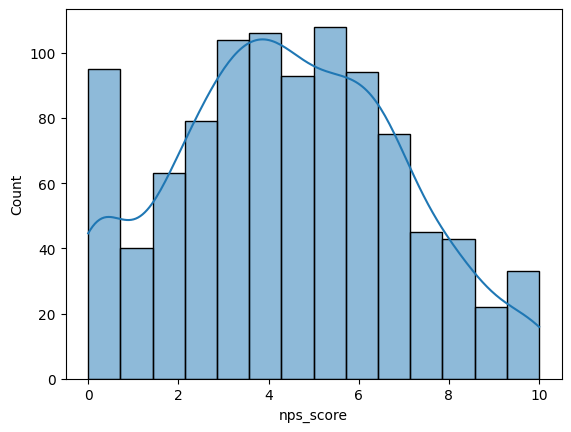

In [ ]:
np.random.seed(42)
nps_data = nps_data.sample(n=1000, replace=False)
sns.histplot(nps_data['nps_score'], kde=True)

Aqui, obtemos um resumo rápido da satisfação geral dos nossos clientes (o 'nps_score'), incluindo a média, o valor mais alto e o mais baixo. É um raio-x da percepção dos clientes.

In [ ]:
display(nps_data['nps_score'].describe())

,nps_score
count,1000.000000
mean,4.416800
std,2.512782
min,0.000000
25%,2.600000
50%,4.300000
75%,6.200000
max,10.000000


Este gráfico nos mostra visualmente se atrasos na entrega (`delivery_delay_days`) afetam a satisfação do cliente (`nps_score`). Queremos entender se há uma relação direta entre o tempo de espera e a percepção do serviço.

In [ ]:
fig = px.scatter(nps_data, x='delivery_delay_days', y='nps_score', title='Correlação entre Atraso na Entrega e NPS Score')
fig.show()

Criamos uma 'regra' para categorizar a satisfação dos clientes com base no `nps_score` deles. Assim, podemos classificá-los em grupos como 'Promotores', 'Passivo' e 'Detratores'.

In [ ]:
def nps_score_class(df):
    if df['nps_score'] >= 9:
        return 'Promotores'
    elif df['nps_score'] >= 7 <= 8:
        return 'Passivos'
    else:
        return 'Detratores'

Aplicamos essa 'regra' a todos os nossos clientes, criando uma nova coluna que mostra a classificação de satisfação de cada um. Isso nos permite ver, por exemplo, quantos clientes são 'Detratores'.

In [ ]:
nps_data['nps_class'] = nps_data.apply(nps_score_class, axis=1)
nps_data

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_class
1447,1448,42,Nordeste,107,51448,435.57,4,85.36,10,3,1,43.82,3,1,7,6.8,0,4,3.7,Detratores
1114,1115,24,Sudeste,118,51115,1110.66,5,20.14,9,6,2,31.05,3,0,5,6.0,0,2,3.8,Detratores
1064,1065,49,Norte,26,51065,395.12,6,133.66,8,5,0,40.72,2,0,8,8.3,1,0,4.6,Passivos
2287,2288,35,Sudeste,80,52288,418.01,3,3.68,6,4,2,36.99,3,0,8,5.3,0,5,3.6,Detratores
1537,1538,42,Sul,102,51538,908.39,4,26.94,9,4,1,44.67,1,1,2,6.8,0,2,6.3,Detratores
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,1005,45,Nordeste,15,51005,819.32,5,26.25,6,5,1,42.99,1,4,3,5.6,0,7,2.6,Detratores
567,568,60,Nordeste,89,50568,461.83,2,14.02,7,6,3,29.26,1,6,4,0.0,0,8,0.0,Detratores
322,323,28,Sudeste,92,50323,981.97,1,0.95,10,10,2,49.78,2,1,0,7.5,0,3,5.5,Passivos
1893,1894,34,Centro-Oeste,70,51894,382.88,5,69.09,8,14,0,50.28,3,2,10,5.3,0,4,2.5,Detratores


Contamos quantos clientes caem em cada categoria de satisfação. Isso nos dá uma visão clara da distribuição dos níveis de satisfação.

In [ ]:
nps_data['nps_class'].value_counts()

,count
nps_class,
Detratores,840
Passivos,119
Promotores,41


Calculamos a média do tempo de entrega, atrasos e satisfação (NPS) para cada região. Essa informação é crucial para identificar áreas com melhor ou pior desempenho.

In [ ]:
nps_data_region_delay = pd.DataFrame(nps_data.groupby('customer_region')[['delivery_time_days','delivery_delay_days','nps_score']].mean().round(2)).reset_index()

Mostramos a tabela com as médias de tempo de entrega, atrasos e NPS para cada região, facilitando a comparação entre elas.

In [ ]:
display(nps_data_region_delay)

,customer_region,delivery_time_days,delivery_delay_days,nps_score
0,Centro-Oeste,8.11,2.26,4.23
1,Nordeste,8.13,2.22,4.42
2,Norte,7.60,2.13,4.32
3,Sudeste,8.09,2.20,4.61
4,Sul,8.02,2.19,4.49


Aqui, vemos quantos clientes de cada categoria de satisfação existem em cada região. Isso ajuda a entender onde temos mais problemas ou sucessos.

In [ ]:
nps_data_region_class_counts = nps_data.groupby('customer_region')['nps_class'].value_counts().reset_index(name='count')
display(nps_data_region_class_counts)

,customer_region,nps_class,count
0,Centro-Oeste,Detratores,156
1,Centro-Oeste,Passivos,15
2,Centro-Oeste,Promotores,8
3,Nordeste,Detratores,166
4,Nordeste,Passivos,23
5,Nordeste,Promotores,7
6,Norte,Detratores,181
7,Norte,Passivos,23
8,Norte,Promotores,8
9,Sudeste,Detratores,169


Este gráfico, chamado 'mapa de calor', nos mostra visualmente as relações entre os fatores e o NPS. Cores mais fortes indicam uma ligação mais intensa, positiva ou negativa.

In [ ]:
influence_columns = [
    'complaints_count',
    'resolution_time_days',
    'customer_service_contacts',
    'delivery_delay_days',
    'delivery_time_days',
    'nps_score'
]

influence_correlation_matrix = nps_data[influence_columns].corr()
display(influence_correlation_matrix)

,complaints_count,resolution_time_days,customer_service_contacts,delivery_delay_days,delivery_time_days,nps_score
complaints_count,1.000000,0.026761,0.757428,0.195328,-0.006509,-0.477175
resolution_time_days,0.026761,1.000000,0.010976,0.003919,0.002364,-0.188102
customer_service_contacts,0.757428,0.010976,1.000000,-0.010895,-0.002850,-0.323889
delivery_delay_days,0.195328,0.003919,-0.010895,1.000000,-0.012593,-0.638861
delivery_time_days,-0.006509,0.002364,-0.002850,-0.012593,1.000000,0.005248
nps_score,-0.477175,-0.188102,-0.323889,-0.638861,0.005248,1.000000


Focamos nos clientes 'Detratores'. Calculamos a média dos problemas (atrasos, reclamações, etc.) *apenas* para eles, para entender o que mais os incomoda e gera essa insatisfação extrema.

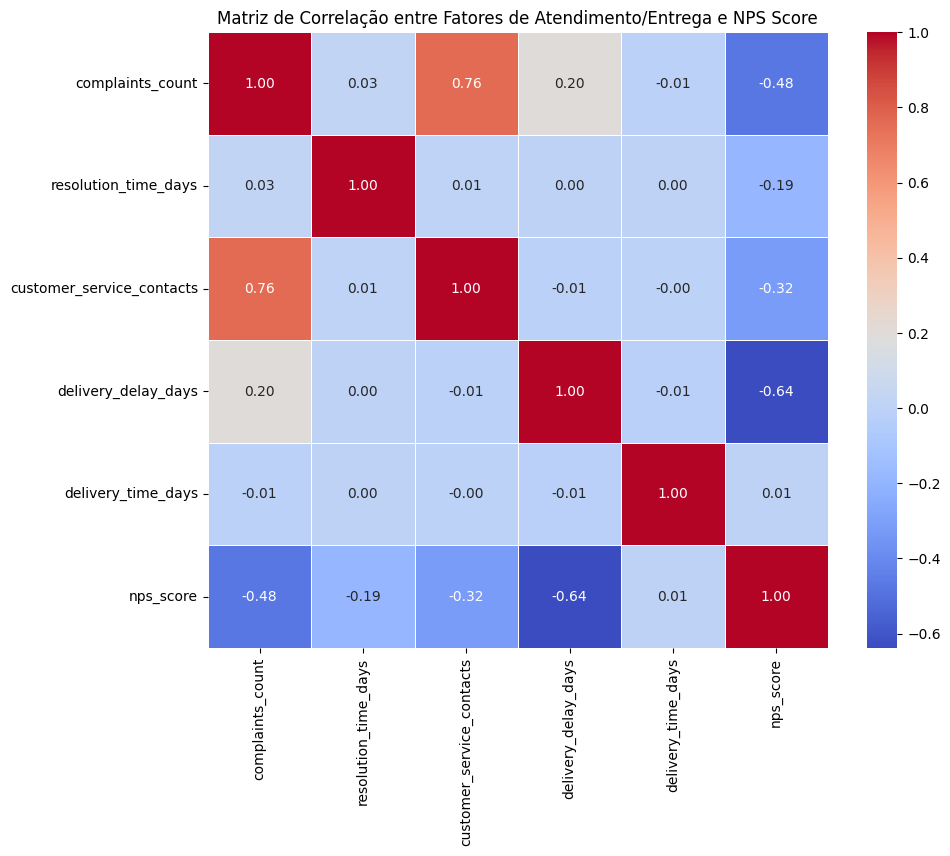

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(influence_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação entre Fatores de Atendimento/Entrega e NPS Score')
plt.show()

## Quais fatores parecem mais críticos para a satisfação?

1. Atraso na entrega: Com uma correlação de **-0.597**, é o fator mais crítico. Grandes atrasos na entrega têm um impacto muito significativo na insatisfação do cliente.
2. Número de reclamações: Com uma correlação de **-0.497**, é o segundo fator mais impactante. Um número elevado de reclamações está fortemente associado a um NPS mais baixo.
3. Contatos com o serviço de atendimento ao cliente: Com uma correlação de **-0.351**, sugere que quanto mais o cliente precisa contatar o serviço, menor tende a ser sua satisfação.
4. Tempo de resolução de problemas: Embora menos impactante que os anteriores com **-0.191**, ainda é um fator negativo. Quanto maior o tempo para resolver um problema, menor a satisfação.






Média dos fatores influenciadores para clientes 'Detratores'

In [ ]:
detractors_data = nps_data[nps_data['nps_class'] == 'Detratores']

detractor_influencing_factors_mean = detractors_data[influence_columns].mean().drop('nps_score')
display(detractor_influencing_factors_mean)

,0
complaints_count,4.454762
resolution_time_days,5.540476
customer_service_contacts,1.653571
delivery_delay_days,2.440476
delivery_time_days,7.964286


Média geral dos fatores influenciadores

In [ ]:
overall_influencing_factors_mean = nps_data[influence_columns].mean().drop('nps_score')
display(overall_influencing_factors_mean)

,0
complaints_count,4.152
resolution_time_days,5.365
customer_service_contacts,1.530
delivery_delay_days,2.198
delivery_time_days,7.983


Este gráfico compara visualmente a média dos problemas para clientes 'Detratores' versus a média geral. Ele mostra de forma clara quais fatores estão desproporcionalmente piores para os insatisfeitos, indicando onde devemos agir.

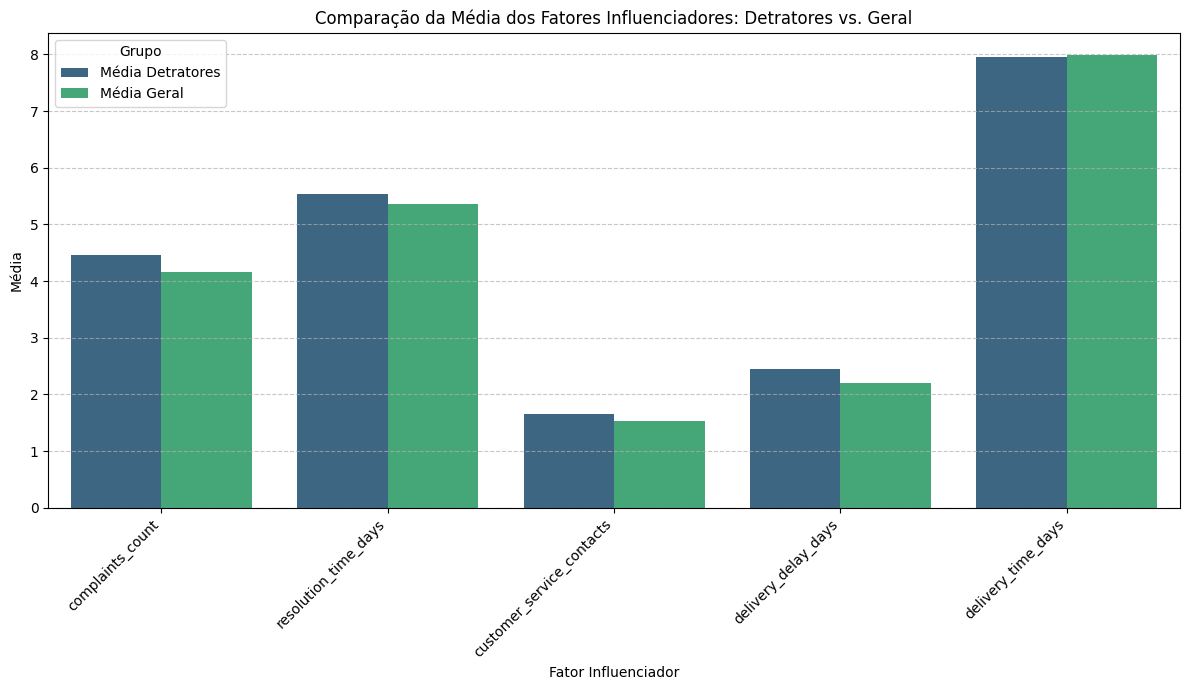

In [ ]:

comparison_df = pd.DataFrame({
    'Fator': detractor_influencing_factors_mean.index,
    'Média Detratores': detractor_influencing_factors_mean.values,
    'Média Geral': overall_influencing_factors_mean.values
})

comparison_df_melted = comparison_df.melt(id_vars='Fator', var_name='Grupo', value_name='Média dos Fatores')

plt.figure(figsize=(12, 7))
sns.barplot(x='Fator', y='Média dos Fatores', hue='Grupo', data=comparison_df_melted, palette='viridis')
plt.title('Comparação da Média dos Fatores Influenciadores: Detratores vs. Geral')
plt.ylabel('Média')
plt.xlabel('Fator Influenciador')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Grupo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## O que mais gera detratores?

* Atraso na Entrega: A média de dias de atraso na entrega para detratores é de 2.44 dias, significativamente maior do que a média geral de 2.19 dias. Isso indica que o atraso na entrega é o maior impulsionador para detratores.

* Número de reclamações: A média de reclamações para os clientes detratores é de 4.45, que é maior do que a média geral de 4.15. Isso indica que um maior volume de reclamações está associado a uma maior insatisfação do cliente


Aqui, analisamos apenas os clientes que *não* compraram novamente nos últimos 30 dias. Calculamos como os problemas (atrasos, reclamações, etc.) se relacionam com a satisfação *neste grupo específico*. O objetivo é entender o que os impede de voltar a comprar.

In [ ]:
no_repeat_purchase_data = nps_data[nps_data['repeat_purchase_30d'] == 0]

no_repeat_purchase_correlation = no_repeat_purchase_data[influence_columns].corr()

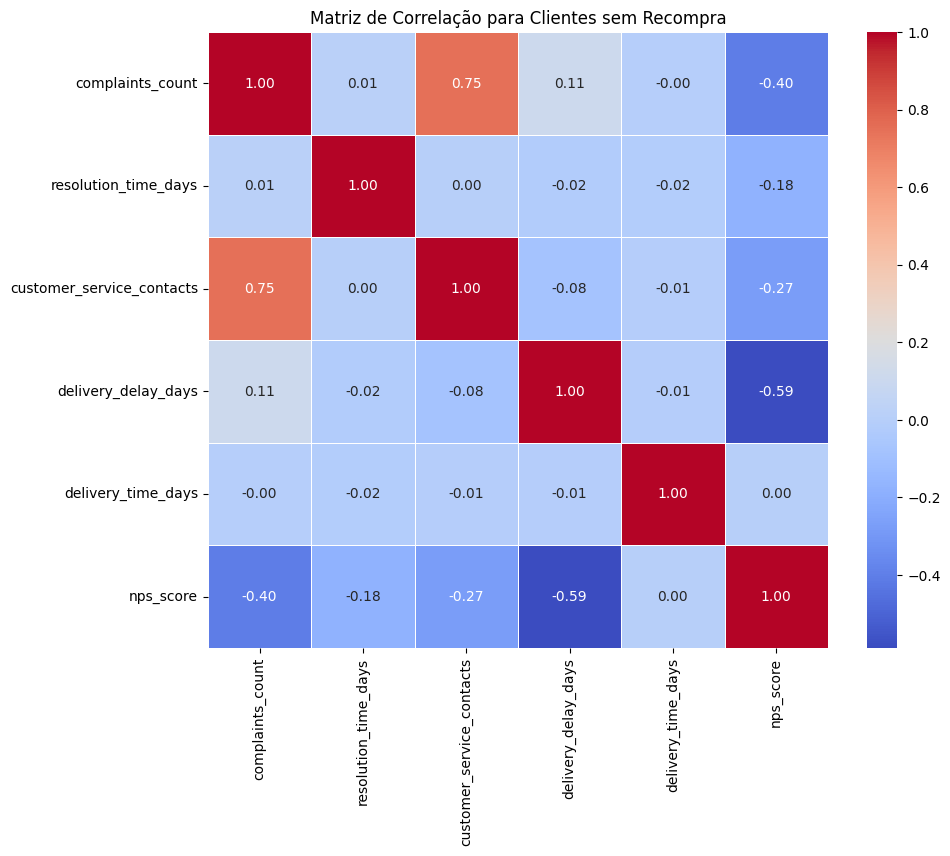

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(no_repeat_purchase_correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação para Clientes sem Recompra')
plt.show()

Qual fator mais critico para clientes que não fizeram recompra?

In [ ]:
correlation_with_nps_no_repeat = no_repeat_purchase_correlation['nps_score'].drop('nps_score')

most_critical_factor_no_repeat = correlation_with_nps_no_repeat.idxmin()
strongest_negative_correlation_no_repeat = correlation_with_nps_no_repeat.min()

display(most_critical_factor_no_repeat)

'delivery_delay_days'

## Existe algum “ponto de ruptura” na experiência do cliente?


*   Sim, o atraso na entrega. Grandes atrasos na entrega têm um impacto muito significativo, que causa o ponto de ruptura e é o maior causador da falta de recompras futuras.




Análise de Clientes com/sem Recompra e NPS

In [ ]:
repeat_purchase_data = nps_data[nps_data['repeat_purchase_30d'] == 1]
no_repeat_purchase_data = nps_data[nps_data['repeat_purchase_30d'] == 0]

promoters_repeat = repeat_purchase_data[repeat_purchase_data['nps_class'] == 'Promotores']
detractors_no_repeat = no_repeat_purchase_data[no_repeat_purchase_data['nps_class'] == 'Detratores']


display(f"Número de Promotores com recompra: {len(promoters_repeat)}")
display(f"Número de Detratores sem recompra: {len(detractors_no_repeat)}")

'Número de Promotores com recompra: 41'

'Número de Detratores sem recompra: 840'

Comparação das Médias de Características Relevantes para Clientes com Recompra

Vamos analisar as médias das mesmas características chave para ambos os grupos: Promotores com recompra e Detratores com recompra.

In [ ]:
comparison_columns = [
    'customer_age',
    'customer_tenure_months',
    'items_quantity',
    'discount_value',
    'payment_installments',
    'freight_value',
    'customer_service_contacts',
    'resolution_time_days',
    'complaints_count',
    'csat_internal_score',
    'delivery_delay_days'
]

promoters_repeat_means = promoters_repeat[comparison_columns].mean().rename('Promotores_Repeat_Mean')
detractors_no_repeat_means = detractors_no_repeat[comparison_columns].mean().rename('Detratores_No_Repeat_Mean')

comparison_df_nps_repeat = pd.DataFrame({
    'Característica': promoters_repeat_means.index,
    'Média Promotores (Com Recompra)': promoters_repeat_means.values,
    'Média Detratores (Sem Recompra)': detractors_no_repeat_means.values
})

display(comparison_df_nps_repeat.round(2))

,Característica,Média Promotores (Com Recompra),Média Detratores (Sem Recompra)
0,customer_age,44.85,43.95
1,customer_tenure_months,70.44,60.88
2,items_quantity,3.27,3.52
3,discount_value,33.49,29.04
4,payment_installments,5.54,6.09
5,freight_value,39.41,38.80
6,customer_service_contacts,0.73,1.65
7,resolution_time_days,3.54,5.54
8,complaints_count,2.20,4.45
9,csat_internal_score,6.34,2.59


Visualização da Comparação (Clientes com Recompra)

Um gráfico de barras para visualizar as diferenças entre os grupos.

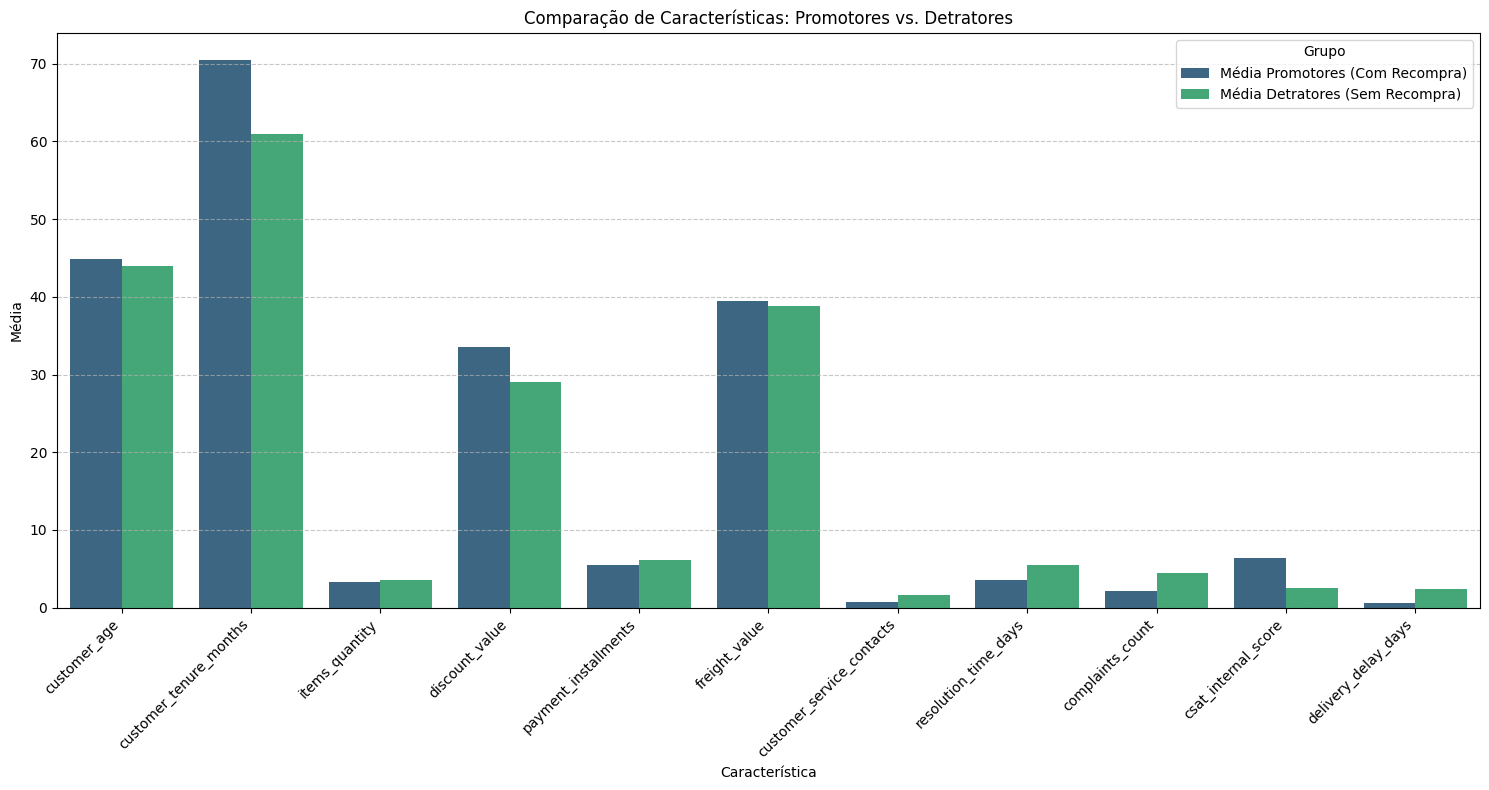

In [ ]:
comparison_df_melted_nps_repeat = comparison_df_nps_repeat.melt(id_vars='Característica', var_name='Grupo', value_name='Média')

plt.figure(figsize=(15, 8))
sns.barplot(x='Característica', y='Média', hue='Grupo', data=comparison_df_melted_nps_repeat, palette='viridis')
plt.title('Comparação de Características: Promotores vs. Detratores')
plt.xlabel('Característica')
plt.ylabel('Média')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Grupo')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Análise de Distribuição Geográfica (Região do Cliente) para Clientes com Recompra

Vamos verificar a distribuição das regiões para Promotores e Detratores que fizeram recompra.

In [ ]:
display("Distribuição de Região para Promotores com Recompra:")
display(promoters_repeat['customer_region'].value_counts(normalize=True).mul(100).round(2))

display("Distribuição de Região para Detratores sem Recompra:")
display(detractors_no_repeat['customer_region'].value_counts(normalize=True).mul(100).round(2))

'Distribuição de Região para Promotores com Recompra:'

,proportion
customer_region,
Sudeste,24.39
Centro-Oeste,19.51
Norte,19.51
Sul,19.51
Nordeste,17.07


'Distribuição de Região para Detratores sem Recompra:'

,proportion
customer_region,
Norte,21.55
Sudeste,20.12
Sul,20.00
Nordeste,19.76
Centro-Oeste,18.57


## Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

**Clientes com NPS mais alto tendem a:**

* Ter realizado recompra nos últimos 30 dias.
* Apresentar maior tempo de relacionamento com a empresa.
* Ter poucos contatos com o atendimento ao cliente.
* Possuir uma nota interna de satisfação mais elevada.
* Residir na região Sudeste.

**Clientes com NPS mais baixo geralmente são impactados por:**

* Atrasos significativos na entrega.
* Longo tempo de resolução de problemas pelo atendimento.
* Um alto número de reclamações.
* Uma baixa nota interna de satisfação.
* Não ter realizado recompra nos últimos 30 dias.









